<a href="https://colab.research.google.com/github/malehzja/final-project/blob/main/final-project/MachineLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Final Project**

# Task 2: Machine Learning
Build a machine learning model and choose the 'best' classifier for your dataset. Also, generate the classification report and confusion matrix.

## Install & Load Libraries

In [1]:
!pip install sklearn

  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


## Load and Read .csv file from GitHub

In [2]:
import requests
import io

url = "https://raw.githubusercontent.com/malehzja/final_lis4693/refs/heads/main/final-project/imdb_tvshows.csv"
response = requests.get(url)
response.raise_for_status() # Raise an exception for HTTP errors
text = response.text

In [3]:
import pandas as pd
df = pd.read_csv(io.StringIO(text), sep = ',')  # File is comma delimited
print(df.head())

   Unnamed: 0  Rating (out of 10)  \
0           0                   9   
1           1                  10   
2           2                  10   
3           3                   9   
4           4                   9   

                                              Review    Show ID   Review ID  
0  Andor was every bit as good as I was hoping fo...  tt9253284  rw10514299  
1  Wow. I just finished episode 12 of the first s...  tt9253284   rw8690571  
2  Andor Season 2 is the best Star Wars Show ever...  tt9253284  rw10514285  
3  There were a few episodes I didn't like in bot...  tt9253284  rw10514788  
4  Didnt like the new movies and even Mandalorian...  tt9253284   rw8665236  


In [4]:
df = df.rename(columns={'Rating (out of 10)': 'Rating'})  # Rename 'Rating (out of 10)' column to 'Rating'

# Create a column that classifies a review as positive (Rating > 5) or negative (Rating <= 5)
df['review_classifier'] = pd.cut(df['Rating'], bins=[0, 5, float('inf')], labels=[1, 0])

In [5]:
print(df.head())

   Unnamed: 0  Rating                                             Review  \
0           0       9  Andor was every bit as good as I was hoping fo...   
1           1      10  Wow. I just finished episode 12 of the first s...   
2           2      10  Andor Season 2 is the best Star Wars Show ever...   
3           3       9  There were a few episodes I didn't like in bot...   
4           4       9  Didnt like the new movies and even Mandalorian...   

     Show ID   Review ID review_classifier  
0  tt9253284  rw10514299                 0  
1  tt9253284   rw8690571                 0  
2  tt9253284  rw10514285                 0  
3  tt9253284  rw10514788                 0  
4  tt9253284   rw8665236                 0  


## Split data into **features** and **target** labels

In [6]:
features = df['Review']
target = df['review_classifier']

In [7]:
target_names = {
    'positive' : '1',
    'negative' : '0'
              }

## Split Data into Training and Test Sets

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.pipeline import Pipeline

# split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Show the results of the split
print("Training set has {} samples.".format(X_train.shape[0]))
print("Testing set has {} samples.".format(X_test.shape[0]))

# Remove or replace NaN values in X_train and X_test
X_train = X_train.fillna('')  # Replace NaN with empty string
X_test = X_test.fillna('')   # Replace NaN with empty string

preprocessing = Pipeline([
    ('vect', CountVectorizer()),
    ('tfidf', TfidfTransformer())
])

print("Preprocessing training data...")
train_preprocessed = preprocessing.fit_transform(X_train)

print("Preprocessing test data...")
test_preprocessed = preprocessing.transform(X_test)

Training set has 6655 samples.
Testing set has 1664 samples.
Preprocessing training data...
Preprocessing test data...


In [10]:
y_test.unique()

[0, 1]
Categories (2, int64): [1 < 0]

## Comparing Classifiers

In [11]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import RandomForestClassifier

nb_classifier = MultinomialNB()
svm_classifier = LinearSVC()
lr_classifier = LogisticRegression(multi_class="ovr")
ada_classifier = AdaBoostClassifier()
random_classifier = RandomForestClassifier()

print("Training Naive Bayes classifier...")
nb_classifier.fit(train_preprocessed, y_train)

print("Training SVM classifier...")
svm_classifier.fit(train_preprocessed, y_train)

print("Training Logistic Regression classifier...")
lr_classifier.fit(train_preprocessed, y_train)

print("Training Adaboost classifier...")
ada_classifier.fit(train_preprocessed, y_train)

print("Training Random Forest classifier...")
random_classifier.fit(train_preprocessed, y_train)

Training Naive Bayes classifier...
Training SVM classifier...
Training Logistic Regression classifier...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Training Adaboost classifier...
Training Random Forest classifier...


RandomForestClassifier()

In [12]:
nb_predictions = nb_classifier.predict(test_preprocessed)
svm_predictions = svm_classifier.predict(test_preprocessed)
lr_predictions = lr_classifier.predict(test_preprocessed)
ada_predictions = ada_classifier.predict(test_preprocessed)
random_predictions = random_classifier.predict(test_preprocessed)

In [13]:
import numpy as np

print("NB Accuracy:", np.mean(nb_predictions == y_test))
print("SVM Accuracy:", np.mean(svm_predictions == y_test))
print("LR Accuracy:", np.mean(lr_predictions == y_test))
print("ADA Accuracy:", np.mean(ada_predictions == y_test))
print("RF Accuracy:", np.mean(random_predictions == y_test))

NB Accuracy: 0.8768028846153846
SVM Accuracy: 0.8695913461538461
LR Accuracy: 0.8768028846153846
ADA Accuracy: 0.8768028846153846
RF Accuracy: 0.8768028846153846


In [14]:
from sklearn.metrics import classification_report  # Import classification_report

print("Naive Bayes:\n")
print(classification_report(y_test, nb_predictions, target_names=target_names))

print("Logistic Regression:\n")
print(classification_report(y_test, lr_predictions, target_names=target_names))

print("AdaBoost:\n")
print(classification_report(y_test, ada_predictions, target_names=target_names))

print("Random Forest:\n")
print(classification_report(y_test, random_predictions, target_names=target_names))

Naive Bayes:

              precision    recall  f1-score   support

    positive       0.88      1.00      0.93      1459
    negative       0.00      0.00      0.00       205

    accuracy                           0.88      1664
   macro avg       0.44      0.50      0.47      1664
weighted avg       0.77      0.88      0.82      1664

Logistic Regression:

              precision    recall  f1-score   support

    positive       0.88      1.00      0.93      1459
    negative       0.00      0.00      0.00       205

    accuracy                           0.88      1664
   macro avg       0.44      0.50      0.47      1664
weighted avg       0.77      0.88      0.82      1664

AdaBoost:

              precision    recall  f1-score   support

    positive       0.88      1.00      0.93      1459
    negative       0.00      0.00      0.00       205

    accuracy                           0.88      1664
   macro avg       0.44      0.50      0.47      1664
weighted avg       0.77    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

(array([0.5, 1.5]), [Text(0.5, 0, 'positive'), Text(1.5, 0, 'negative')])

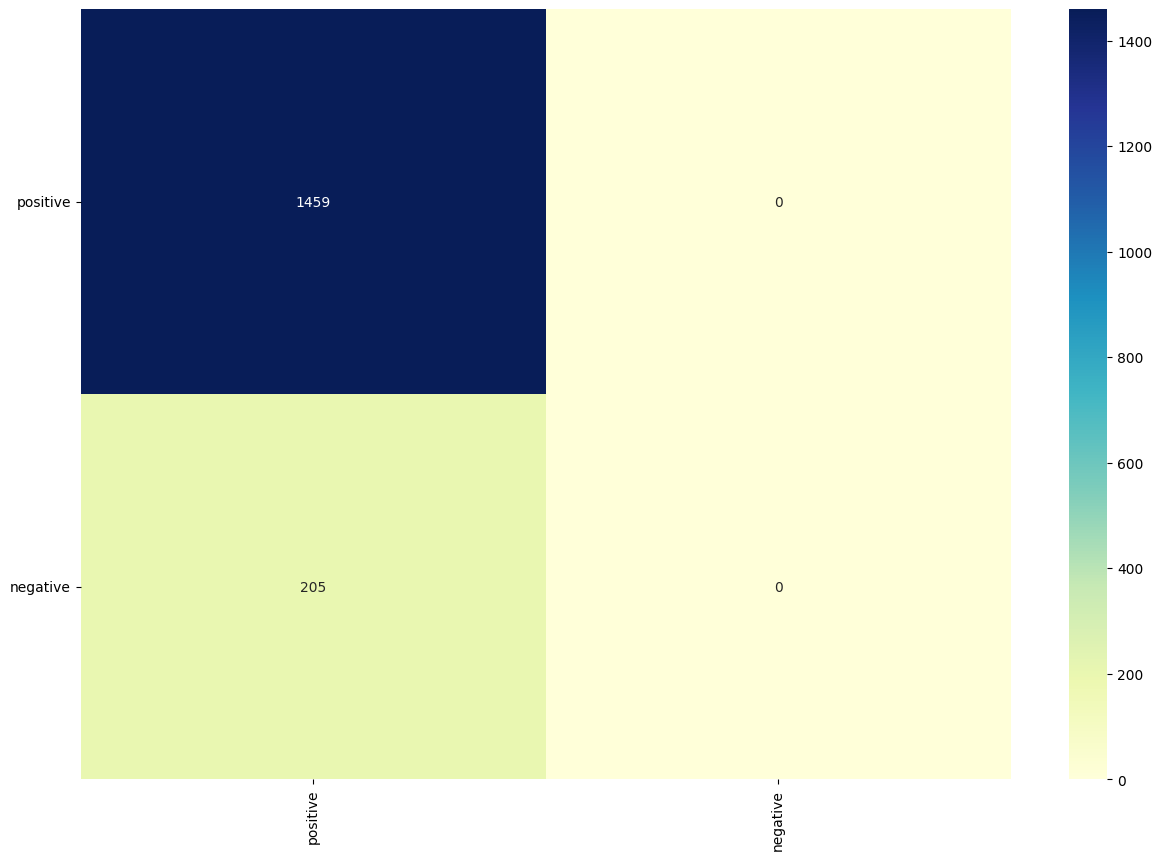

In [15]:
from sklearn.metrics import classification_report, confusion_matrix
%matplotlib inline
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt

conf_matrix = confusion_matrix(y_test, ada_predictions)
conf_matrix_df = pd.DataFrame(conf_matrix, index=target_names, columns=target_names)

plt.figure(figsize=(15, 10))
x = sn.heatmap(conf_matrix_df, annot=True, vmin=0, vmax=conf_matrix.max(), fmt='d', cmap="YlGnBu")
plt.yticks(rotation=0)
plt.xticks(rotation=90)